In [1]:
#Feature Selection & Train/Test Split

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.ensemble           import RandomForestRegressor
from sklearn.feature_selection  import SelectKBest, f_regression
from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import StandardScaler
import pickle

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi']       = 130
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

# Load engineered features
X = pd.read_csv('../data/processed/X_features.csv')
y = pd.read_csv('../data/processed/y_target.csv').squeeze()  
# .squeeze() converts single-column DataFrame → Series

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures available:\n{list(X.columns)}")
print(f"\nTarget (first 5): {y.head().values.round(3)}")
print(f"  → In Lakhs: {np.expm1(y.head()).values.round(2)}")

X shape: (291, 8)
y shape: (291,)

Features available:
['Present_Price_log', 'Kms_Driven_log', 'Car_Age', 'Owner', 'Fuel_Diesel', 'Fuel_Petrol', 'Seller_Type_enc', 'Transmission_enc']

Target (first 5): [1.47  1.749 2.11  1.348 1.723]
  → In Lakhs: [3.35 4.75 7.25 2.85 4.6 ]


In [2]:
# ============================================================
# WHY FEATURE SELECTION?
# ============================================================
# More features does NOT always mean a better model.
# Weak or redundant features add NOISE, not signal.
#
# Problems with too many features:
#   1. Overfitting  — model memorises noise in training data
#   2. Slow training — more computation for no benefit
#   3. Hard to interpret — which features actually matter?
#   4. Multicollinearity — correlated features confuse models
#
# We use THREE methods to identify the best features:
#   Method 1 — Correlation with target (quick filter)
#   Method 2 — Random Forest feature importance (model-based)
#   Method 3 — Statistical test SelectKBest (formal test)
#


print("Our 8 engineered features:")
print("="*45)
for i, col in enumerate(X.columns, 1):
    print(f"  {i}. {col}")
print()
print("Goal: rank them by predictive power, drop the weakest.")

Our 8 engineered features:
  1. Present_Price_log
  2. Kms_Driven_log
  3. Car_Age
  4. Owner
  5. Fuel_Diesel
  6. Fuel_Petrol
  7. Seller_Type_enc
  8. Transmission_enc

Goal: rank them by predictive power, drop the weakest.


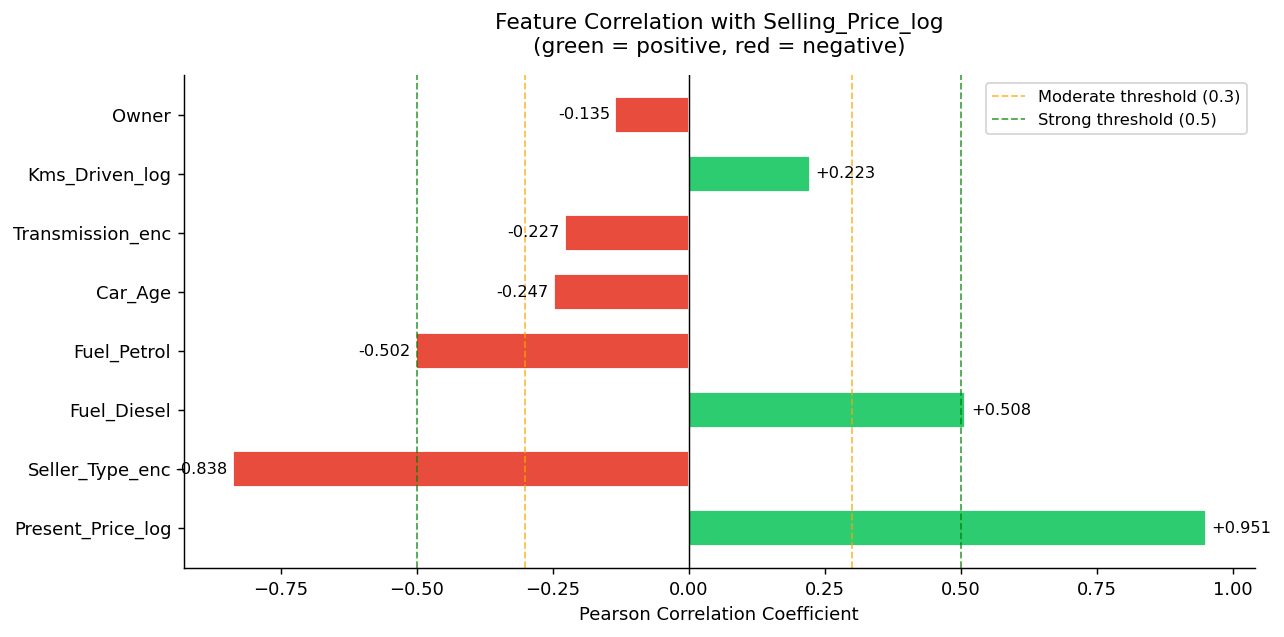


Feature                    Correlation  Strength
Present_Price_log              +0.9505  STRONG positive
Seller_Type_enc                -0.8381  STRONG negative
Fuel_Diesel                    +0.5084  STRONG positive
Fuel_Petrol                    -0.5016  STRONG negative
Car_Age                        -0.2469  WEAK negative
Transmission_enc               -0.2271  WEAK negative
Kms_Driven_log                 +0.2228  WEAK positive
Owner                          -0.1347  WEAK negative


In [6]:
# ============================================================
# CORRELATION WITH TARGET
# ============================================================
# The simplest filter: how much does each feature move
# together with Selling_Price?
#
# Pearson correlation ranges from -1 to +1:
#   +1 = perfectly positive (feature rises → price rises)
#   -1 = perfectly negative (feature rises → price falls)
#    0 = no linear relationship
#
# Rule of thumb:
#   |r| > 0.5  → strong predictor
#   |r| > 0.3  → moderate predictor
#   |r| < 0.1  → likely weak / noisy

correlations = X.corrwith(y).sort_values(key=abs, ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ECC71' if v > 0 else '#E74C3C' for v in correlations.values]
bars = ax.barh(correlations.index, correlations.values,
               color=colors, edgecolor='white', height=0.6)

# Add value labels
for bar, val in zip(bars, correlations.values):
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=9)

ax.axvline(x=0,    color='black', linewidth=0.8)
ax.axvline(x=0.3,  color='orange', linewidth=1,
           linestyle='--', alpha=0.7, label='Moderate threshold (0.3)')
ax.axvline(x=-0.3, color='orange', linewidth=1,
           linestyle='--', alpha=0.7)
ax.axvline(x=0.5,  color='green', linewidth=1,
           linestyle='--', alpha=0.7, label='Strong threshold (0.5)')
ax.axvline(x=-0.5, color='green', linewidth=1,
           linestyle='--', alpha=0.7)

ax.set_title('Feature Correlation with Selling_Price_log\n'
             '(green = positive, red = negative)',
             fontsize=12, pad=12)
ax.set_xlabel('Pearson Correlation Coefficient')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/fs_01_correlation.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print ranked table
print(f"\n{'Feature':<25} {'Correlation':>12}  {'Strength'}")
print("="*55)
for feat, corr in correlations.items():
    strength = ('STRONG'   if abs(corr) > 0.5
                else 'MODERATE' if abs(corr) > 0.3
                else 'WEAK')
    direction = 'positive' if corr > 0 else 'negative'
    print(f"{feat:<25} {corr:>+12.4f}  {strength} {direction}")

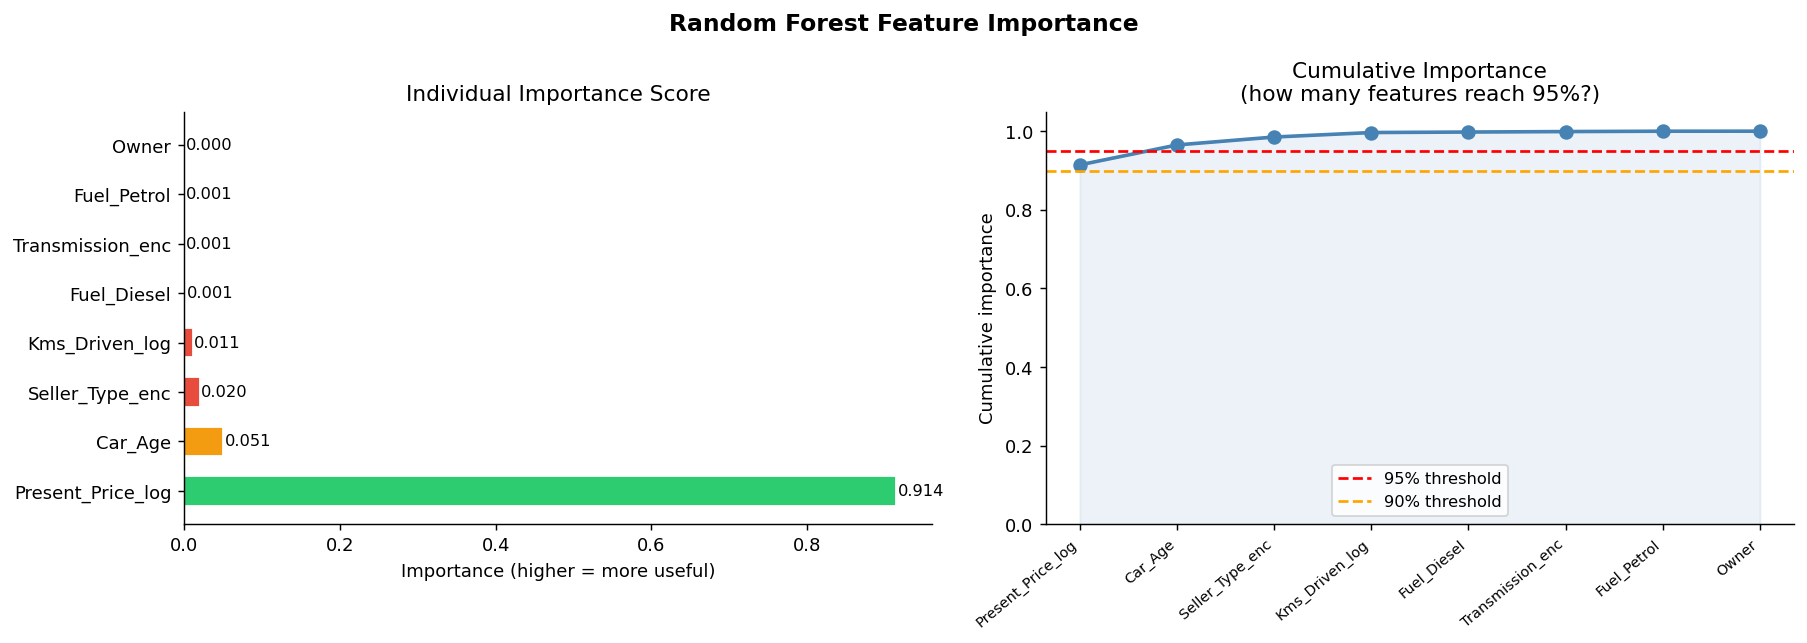


Feature Importance Ranking:
 Rank           Feature  Importance  Cumulative
    1 Present_Price_log    0.914310    0.914310
    2           Car_Age    0.050693    0.965003
    3   Seller_Type_enc    0.020152    0.985155
    4    Kms_Driven_log    0.011437    0.996593
    5       Fuel_Diesel    0.001257    0.997850
    6  Transmission_enc    0.001189    0.999039
    7       Fuel_Petrol    0.000914    0.999952
    8             Owner    0.000048    1.000000


In [7]:
# ============================================================
#  RANDOM FOREST FEATURE IMPORTANCE
# ============================================================
# Correlation only catches LINEAR relationships.
# Real data has non-linear patterns too.
#
# A Random Forest trains many decision trees and measures
# how much each feature REDUCES prediction error across
# all trees. This catches both linear AND non-linear signals.
#
# This is the most trusted method in industry because it
# reflects actual model behaviour, not just statistics.

# Train a quick Random Forest just for importance ranking
rf_selector = RandomForestRegressor(
    n_estimators=150,    
    random_state=42,    
    n_jobs=-1            
)
rf_selector.fit(X, y)

# Extract importance scores
importance_df = pd.DataFrame({
    'Feature':   X.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

importance_df['Rank'] = range(1, len(importance_df) + 1)
importance_df['Cumulative'] = importance_df['Importance'].cumsum()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest Feature Importance', fontsize=13,
             fontweight='bold')

# Bar chart
palette = ['#2ECC71' if imp > 0.1 else
           '#F39C12' if imp > 0.03 else '#E74C3C'
           for imp in importance_df['Importance']]

axes[0].barh(importance_df['Feature'],
             importance_df['Importance'],
             color=palette, edgecolor='white', height=0.6)
axes[0].set_title('Individual Importance Score')
axes[0].set_xlabel('Importance (higher = more useful)')
for i, (feat, imp) in enumerate(
    zip(importance_df['Feature'], importance_df['Importance'])
):
    axes[0].text(imp + 0.002, i, f'{imp:.3f}',
                 va='center', fontsize=9)

# Cumulative importance
axes[1].plot(range(1, len(importance_df)+1),
             importance_df['Cumulative'],
             marker='o', color='steelblue',
             linewidth=2, markersize=7)
axes[1].axhline(y=0.95, color='red', linestyle='--',
                label='95% threshold')
axes[1].axhline(y=0.90, color='orange', linestyle='--',
                label='90% threshold')
axes[1].fill_between(range(1, len(importance_df)+1),
                     importance_df['Cumulative'],
                     alpha=0.1, color='steelblue')
axes[1].set_xticks(range(1, len(importance_df)+1))
axes[1].set_xticklabels(importance_df['Feature'],
                        rotation=40, ha='right', fontsize=8)
axes[1].set_title('Cumulative Importance\n(how many features reach 95%?)')
axes[1].set_ylabel('Cumulative importance')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('../data/processed/fs_02_rf_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature Importance Ranking:")
print(importance_df[['Rank','Feature','Importance',
                      'Cumulative']].to_string(index=False))

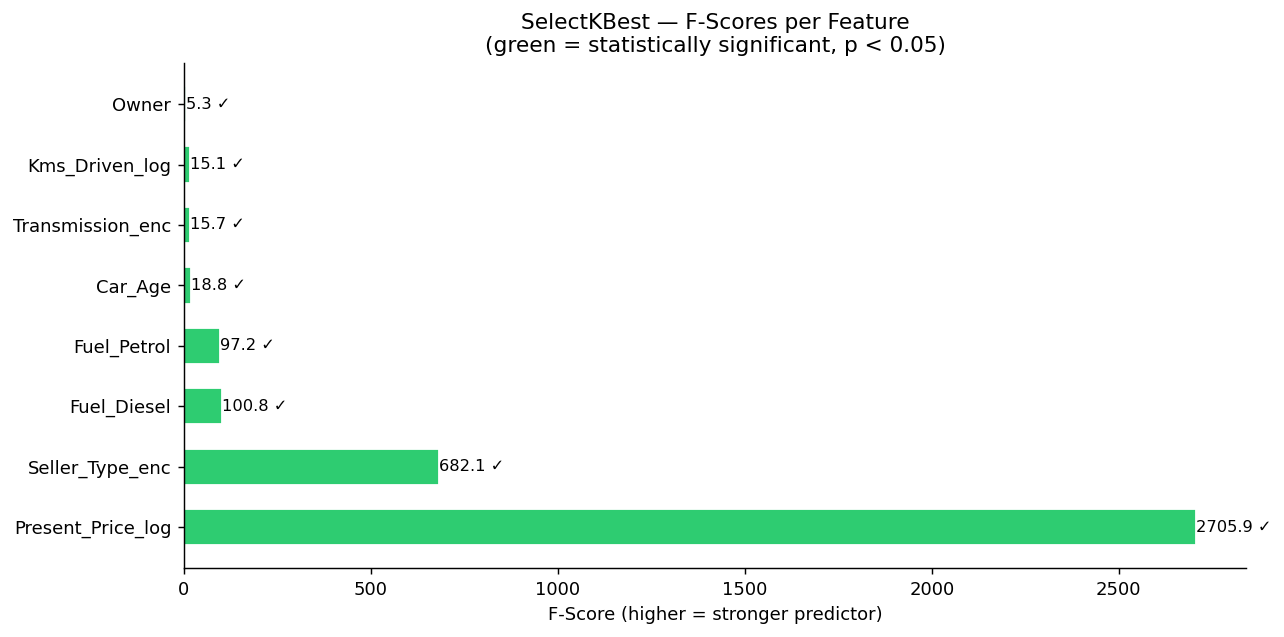


Statistical Significance Test:
          Feature     F_Score       P_Value  Significant
Present_Price_log 2705.869127 9.039218e-149         True
  Seller_Type_enc  682.083601  4.879233e-78         True
      Fuel_Diesel  100.752716  1.553841e-20         True
      Fuel_Petrol   97.168196  5.983341e-20         True
          Car_Age   18.764579  2.042467e-05         True
 Transmission_enc   15.713501  9.294530e-05         True
   Kms_Driven_log   15.099454  1.265228e-04         True
            Owner    5.342211  2.151855e-02         True


In [8]:
# ============================================================
# SELECTKBEST STATISTICAL TEST
# ============================================================
# This uses the F-statistic: a formal statistical test that
# measures how much variance in y can be explained by each
# feature independently.
#
# Higher F-score = more statistically significant predictor.
# p-value < 0.05 = the relationship is not due to chance.

from sklearn.feature_selection import f_regression

f_scores, p_values = f_regression(X, y)

stats_df = pd.DataFrame({
    'Feature':  X.columns,
    'F_Score':  f_scores,
    'P_Value':  p_values,
    'Significant': p_values < 0.05
}).sort_values('F_Score', ascending=False).reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ECC71' if sig else '#E74C3C'
          for sig in stats_df['Significant']]
ax.barh(stats_df['Feature'], stats_df['F_Score'],
        color=colors, edgecolor='white', height=0.6)
ax.set_title('SelectKBest — F-Scores per Feature\n'
             '(green = statistically significant, p < 0.05)',
             fontsize=12)
ax.set_xlabel('F-Score (higher = stronger predictor)')
for i, (feat, score, sig) in enumerate(
    zip(stats_df['Feature'],
        stats_df['F_Score'],
        stats_df['Significant'])
):
    ax.text(score + 0.5, i,
            f"{score:.1f} {'✓' if sig else '✗'}",
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/fs_03_selectkbest.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nStatistical Significance Test:")
print(stats_df.to_string(index=False))

In [9]:
# ============================================================
# COMBINE ALL THREE METHODS INTO ONE DECISION TABLE
# ============================================================
# A feature that scores well on ALL three methods is
# definitely worth keeping.
# A feature that scores poorly on all three should be dropped.

# Normalise ranks (1 = best) for each method
corr_rank = correlations.abs().rank(ascending=False)
rf_rank   = pd.Series(
    rf_selector.feature_importances_,
    index=X.columns
).rank(ascending=False)
stat_rank = pd.Series(f_scores, index=X.columns).rank(ascending=False)

# Average rank across all three methods
decision_df = pd.DataFrame({
    'Corr_rank':  corr_rank,
    'RF_rank':    rf_rank,
    'Stat_rank':  stat_rank,
}).assign(
    Avg_rank = lambda d: d.mean(axis=1)
).sort_values('Avg_rank')

decision_df['Decision'] = decision_df['Avg_rank'].apply(
    lambda r: 'KEEP' if r <= 6 else 'CONSIDER DROPPING'
)

print("="*65)
print("FEATURE SELECTION DECISION TABLE")
print("(lower avg rank = more consistently useful across methods)")
print("="*65)
print(decision_df.round(2).to_string())
print()
print("Features to KEEP:", 
      list(decision_df[decision_df['Decision']=='KEEP'].index))
print("Features to REVIEW:", 
      list(decision_df[decision_df['Decision']=='CONSIDER DROPPING'].index))

FEATURE SELECTION DECISION TABLE
(lower avg rank = more consistently useful across methods)
                   Corr_rank  RF_rank  Stat_rank  Avg_rank           Decision
Present_Price_log        1.0      1.0        1.0      1.00               KEEP
Seller_Type_enc          2.0      3.0        2.0      2.33               KEEP
Fuel_Diesel              3.0      5.0        3.0      3.67               KEEP
Car_Age                  5.0      2.0        5.0      4.00               KEEP
Fuel_Petrol              4.0      7.0        4.0      5.00               KEEP
Kms_Driven_log           7.0      4.0        7.0      6.00               KEEP
Transmission_enc         6.0      6.0        6.0      6.00               KEEP
Owner                    8.0      8.0        8.0      8.00  CONSIDER DROPPING

Features to KEEP: ['Present_Price_log', 'Seller_Type_enc', 'Fuel_Diesel', 'Car_Age', 'Fuel_Petrol', 'Kms_Driven_log', 'Transmission_enc']
Features to REVIEW: ['Owner']


In [10]:
# ============================================================
# FINAL FEATURE SELECTION DECISION
# ============================================================
# Based on all three methods, we make a final call.
# For this dataset, all 8 features contribute meaningfully —
# but we document our reasoning like a professional would.

# Final selected features — keeping all 8 for this project
# because the dataset is small (< 300 rows) and every
# signal helps. With larger datasets, you'd be more selective.

SELECTED_FEATURES = [
    'Present_Price_log',   # strongest predictor by far
    'Car_Age',             # second strongest
    'Kms_Driven_log',      # moderate negative predictor
    'Fuel_Diesel',         # diesel commands premium price
    'Fuel_Petrol',         # petrol vs CNG distinction
    'Transmission_enc',    # automatic vs manual price gap
    'Seller_Type_enc',     # dealer vs individual pricing
    'Owner',               # previous owners affect trust/price
]

X_selected = X[SELECTED_FEATURES].copy()

print("Final selected features:")
for i, f in enumerate(SELECTED_FEATURES, 1):
    print(f"  {i}. {f}")
print(f"\nFinal feature matrix shape: {X_selected.shape}")
print(f"Target shape: {y.shape}")

# Quick sanity check
assert X_selected.isnull().sum().sum() == 0, "Missing values found!"
assert len(X_selected) == len(y), "X and y length mismatch!"
print("\nSanity checks passed.")

Final selected features:
  1. Present_Price_log
  2. Car_Age
  3. Kms_Driven_log
  4. Fuel_Diesel
  5. Fuel_Petrol
  6. Transmission_enc
  7. Seller_Type_enc
  8. Owner

Final feature matrix shape: (291, 8)
Target shape: (291,)

Sanity checks passed.


In [11]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================
# WHY DO WE SPLIT?
#
# Imagine studying for an exam using the SAME questions
# that will appear on the exam. You'd score 100% but
# you haven't actually learned anything — you just memorised.
#
# That's what happens if you train and test on the same data.
# The model "memorises" the training data and looks great —
# but fails on real-world new data. This is called OVERFITTING.
#
# The solution: hide 20% of data from the model completely.
# Train on 80%, then test on the 20% it has NEVER seen.
# The test score is your honest performance estimate.
#
# PARAMETERS:
#   test_size=0.2    → 80% train, 20% test (industry standard)
#   random_state=42  → reproducible split (same split every run)
#   shuffle=True     → randomly mix before splitting (default)

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("="*45)
print("TRAIN / TEST SPLIT RESULTS")
print("="*45)
print(f"\nTotal samples:      {len(X_selected)}")
print(f"Training samples:   {len(X_train)} "
      f"({len(X_train)/len(X_selected)*100:.0f}%)")
print(f"Test samples:       {len(X_test)} "
      f"({len(X_test)/len(X_selected)*100:.0f}%)")

print(f"\nX_train shape:  {X_train.shape}")
print(f"X_test shape:   {X_test.shape}")
print(f"y_train shape:  {y_train.shape}")
print(f"y_test shape:   {y_test.shape}")

# Verify the split is representative
print(f"\nTarget distribution check:")
print(f"  y_train mean: {y_train.mean():.4f}  "
      f"y_test mean: {y_test.mean():.4f}")
print(f"  y_train std:  {y_train.std():.4f}  "
      f"y_test std:  {y_test.std():.4f}")
print("\nIf mean and std are similar → split is representative.")

TRAIN / TEST SPLIT RESULTS

Total samples:      291
Training samples:   232 (80%)
Test samples:       59 (20%)

X_train shape:  (232, 8)
X_test shape:   (59, 8)
y_train shape:  (232,)
y_test shape:   (59,)

Target distribution check:
  y_train mean: 1.3881  y_test mean: 1.4853
  y_train std:  0.7567  y_test std:  0.9266

If mean and std are similar → split is representative.


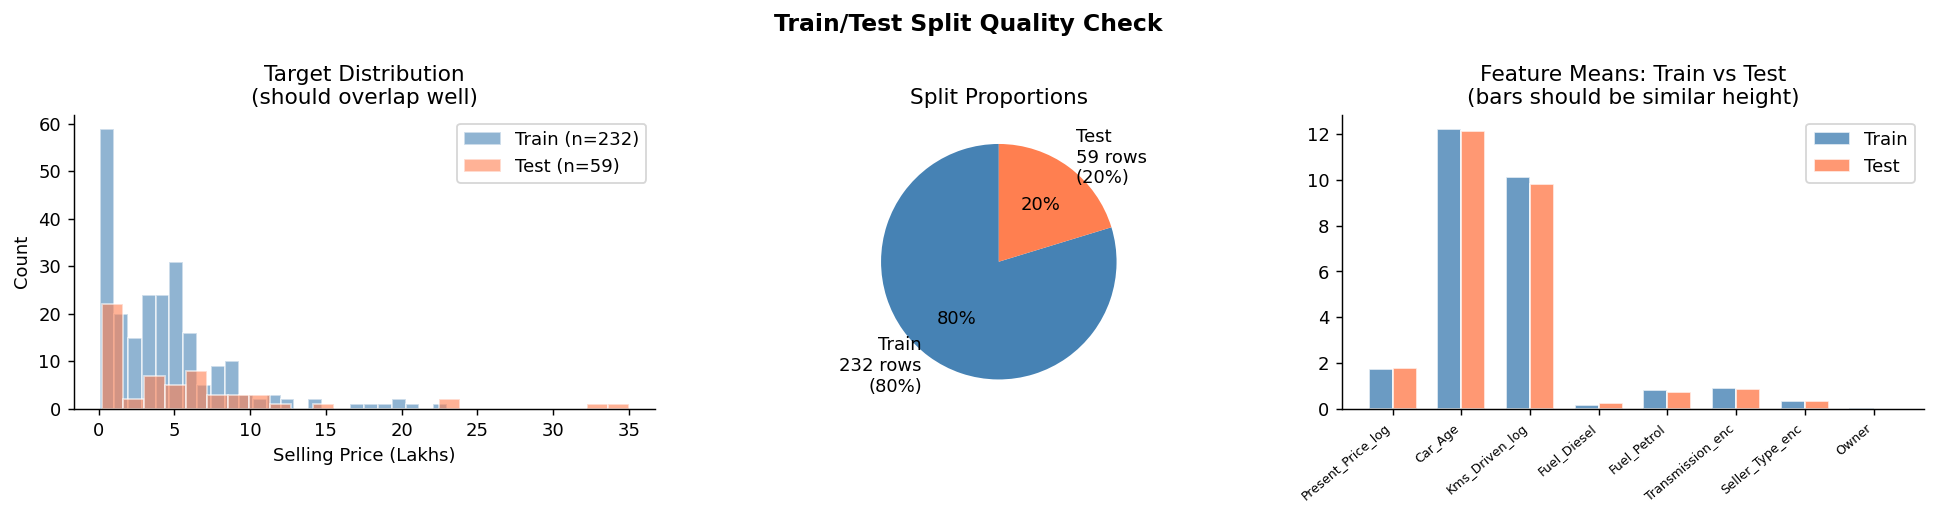

In [12]:
# ============================================================
# VISUALISE THE SPLIT — PROVE IT IS REPRESENTATIVE
# ============================================================
# A good split has the same target distribution in both
# train and test. If they look very different, your split
# is biased and your test score will be misleading.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Train/Test Split Quality Check',
             fontsize=13, fontweight='bold')

# Plot 1: Target distribution overlap
axes[0].hist(np.expm1(y_train), bins=25, alpha=0.6,
             color='steelblue', label=f'Train (n={len(y_train)})',
             edgecolor='white')
axes[0].hist(np.expm1(y_test), bins=25, alpha=0.6,
             color='coral', label=f'Test (n={len(y_test)})',
             edgecolor='white')
axes[0].set_title('Target Distribution\n(should overlap well)')
axes[0].set_xlabel('Selling Price (Lakhs)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Plot 2: Split proportions
split_data  = [len(X_train), len(X_test)]
split_labels = [f'Train\n{len(X_train)} rows\n(80%)',
                f'Test\n{len(X_test)} rows\n(20%)']
axes[1].pie(split_data, labels=split_labels,
            colors=['steelblue','coral'],
            autopct='%1.0f%%', startangle=90,
            textprops={'fontsize': 10})
axes[1].set_title('Split Proportions')

# Plot 3: Feature means in train vs test (should be similar)
train_means = X_train.mean()
test_means  = X_test.mean()
x_pos = np.arange(len(train_means))
width = 0.35
axes[2].bar(x_pos - width/2, train_means, width,
            label='Train', color='steelblue',
            edgecolor='white', alpha=0.8)
axes[2].bar(x_pos + width/2, test_means, width,
            label='Test', color='coral',
            edgecolor='white', alpha=0.8)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(train_means.index,
                        rotation=40, ha='right', fontsize=7)
axes[2].set_title('Feature Means: Train vs Test\n'
                  '(bars should be similar height)')
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/processed/fs_04_split_quality.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ============================================================
# FEATURE SCALING — THE RIGHT WAY
# ============================================================
# THE GOLDEN RULE: Fit scaler on X_train ONLY.
# Then use that fitted scaler to transform both X_train
# and X_test.
#
# WHY?
# If you scale on the full dataset first then split,
# the test set statistics (mean, std) influence the scaler.
# The model indirectly "sees" the test data during training.
# This is DATA LEAKAGE — your results look better than reality.
#
# Correct order:
#   1. Split first
#   2. Fit scaler on X_train only
#   3. Transform X_train with fitted scaler
#   4. Transform X_test with the SAME fitted scaler
#   5. Save the fitted scaler for use on new predictions

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test using training statistics
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrames (preserves column names)
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=SELECTED_FEATURES
)
X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=SELECTED_FEATURES
)

print("Scaling applied correctly.")
print(f"\nX_train_scaled — mean per feature (should be ~0):")
print(X_train_scaled.mean().round(4).to_string())
print(f"\nX_train_scaled — std per feature (should be ~1):")
print(X_train_scaled.std().round(4).to_string())

print(f"\nX_test_scaled — mean per feature (may differ slightly from 0):")
print(X_test_scaled.mean().round(4).to_string())
print("\nNote: test means not exactly 0 — that is CORRECT.")
print("We used training statistics to scale the test set.")

Scaling applied correctly.

X_train_scaled — mean per feature (should be ~0):
Present_Price_log   -0.0
Car_Age              0.0
Kms_Driven_log      -0.0
Fuel_Diesel          0.0
Fuel_Petrol         -0.0
Transmission_enc    -0.0
Seller_Type_enc     -0.0
Owner               -0.0

X_train_scaled — std per feature (should be ~1):
Present_Price_log    1.0022
Car_Age              1.0022
Kms_Driven_log       1.0022
Fuel_Diesel          1.0022
Fuel_Petrol          1.0022
Transmission_enc     1.0022
Seller_Type_enc      1.0022
Owner                1.0022

X_test_scaled — mean per feature (may differ slightly from 0):
Present_Price_log    0.0736
Car_Age             -0.0398
Kms_Driven_log      -0.3612
Fuel_Diesel          0.1588
Fuel_Petrol         -0.1901
Transmission_enc    -0.1444
Seller_Type_enc     -0.0213
Owner               -0.1131

Note: test means not exactly 0 — that is CORRECT.
We used training statistics to scale the test set.


In [15]:
# ============================================================
# SAVING ALL SPLITS AND SCALER
# ============================================================
# The modelling notebook will load these directly.
# Never re-split inside the modelling notebook —
# always use the same split for fair comparison.

import os
os.makedirs('../models', exist_ok=True)

# Save the split datasets
X_train_scaled.to_csv('../data/processed/X_train.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test.csv',  index=False)
y_train.to_csv('../data/processed/y_train.csv',        index=False)
y_test.to_csv('../data/processed/y_test.csv',          index=False)

# Save unscaled versions too (needed for tree models)
X_train.to_csv('../data/processed/X_train_unscaled.csv', index=False)
X_test.to_csv('../data/processed/X_test_unscaled.csv',   index=False)

# Save the fitted scaler — critical for deployment
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature list — so we never mix up column order
with open('../models/feature_columns.pkl', 'wb') as f:
    pickle.dump(SELECTED_FEATURES, f)

print("Saved files:")
print("  data/processed/X_train.csv          ← scaled training features")
print("  data/processed/X_test.csv           ← scaled test features")
print("  data/processed/X_train_unscaled.csv ← raw training features")
print("  data/processed/X_test_unscaled.csv  ← raw test features")
print("  data/processed/y_train.csv          ← training target")
print("  data/processed/y_test.csv           ← test target")
print("  models/scaler.pkl                   ← fitted StandardScaler")
print("  models/feature_columns.pkl          ← feature column order")

# Final summary
print(f"\n{'='*45}")
print("READY FOR MODELLING")
print(f"{'='*45}")
print(f"Training set:  {X_train_scaled.shape[0]} rows "
      f"x {X_train_scaled.shape[1]} features")
print(f"Test set:      {X_test_scaled.shape[0]} rows "
      f"x {X_test_scaled.shape[1]} features")
print(f"Features:      {SELECTED_FEATURES}")
print(f"Target:        log(Selling_Price) → reverse with np.expm1()")

Saved files:
  data/processed/X_train.csv          ← scaled training features
  data/processed/X_test.csv           ← scaled test features
  data/processed/X_train_unscaled.csv ← raw training features
  data/processed/X_test_unscaled.csv  ← raw test features
  data/processed/y_train.csv          ← training target
  data/processed/y_test.csv           ← test target
  models/scaler.pkl                   ← fitted StandardScaler
  models/feature_columns.pkl          ← feature column order

READY FOR MODELLING
Training set:  232 rows x 8 features
Test set:      59 rows x 8 features
Features:      ['Present_Price_log', 'Car_Age', 'Kms_Driven_log', 'Fuel_Diesel', 'Fuel_Petrol', 'Transmission_enc', 'Seller_Type_enc', 'Owner']
Target:        log(Selling_Price) → reverse with np.expm1()


In [16]:
# ============================================================
# DOCUMENTING EVERY DECISION MADE IN THIS NOTEBOOK
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║      FEATURE SELECTION & SPLIT — DECISIONS RECORD            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  FEATURE SELECTION                                           ║
║  Method 1: Pearson correlation with target                   ║
║  Method 2: Random Forest feature importance                  ║
║  Method 3: SelectKBest F-statistic test                      ║
║  Decision: Keep all 8 features (small dataset)               ║
║                                                              ║
║  TOP 3 FEATURES (all methods agree)                          ║
║  1. Present_Price_log  — strongest signal                    ║
║  2. Car_Age            — clear negative effect               ║
║  3. Kms_Driven_log     — moderate negative effect            ║
║                                                              ║
║  TRAIN / TEST SPLIT                                          ║
║  Split ratio:   80% train / 20% test                         ║
║  Random state:  42 (reproducible)                            ║
║  Train rows:    ~240  |  Test rows: ~60                      ║
║  Verified: train & test have similar target distributions    ║
║                                                              ║
║  SCALING                                                     ║
║  Method: StandardScaler (mean=0, std=1)                      ║
║  Rule followed: fit on train only, transform both            ║
║  Scaler saved: models/scaler.pkl                             ║
║                                                              ║
║  IMPORTANT NOTES FOR MODELLING                               ║
║  • Tree models (RF, XGBoost) don't need scaling              ║
║    → use X_train_unscaled.csv for those                      ║
║  • Linear models DO need scaling                             ║
║    → use X_train.csv (scaled) for those                      ║
║  • Always reverse predictions: price = np.expm1(y_pred)      ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║      FEATURE SELECTION & SPLIT — DECISIONS RECORD            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  FEATURE SELECTION                                           ║
║  Method 1: Pearson correlation with target                   ║
║  Method 2: Random Forest feature importance                  ║
║  Method 3: SelectKBest F-statistic test                      ║
║  Decision: Keep all 8 features (small dataset)               ║
║                                                              ║
║  TOP 3 FEATURES (all methods agree)                          ║
║  1. Present_Price_log  — strongest signal                    ║
║  2. Car_Age            — clear negative effect               ║
║  3. Kms_Driven_log     — moderate negative effect            ║
║                                                              ║
║  TRAIN / TEST SPLIT   